# NumerAI Rapid Research Template

In [8]:
import sys
import warnings
from pathlib import Path
import os

import pandas as pd
from sklearn.base import clone

warnings.filterwarnings("ignore")

NOTEBOOK_PATH = Path(
    globals().get("__vsc_ipynb_file__", Path.cwd() / "template.ipynb")
).resolve()
    
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from utils.data import (
    align_on_id,
    apply_validation_embargo,
    build_dataset_columns,
    load_benchmark_frame,
    load_feature_set,
    read_parquet_with_id_index,
)
from utils.metrics import calculate_metrics
from utils.postprocessing import build_evaluation_frame, neutralize_by_era, rank_by_era
from utils.visualization import display_metrics_table, plot_metric_over_time

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [9]:
DATA_VERSION = "v5.2"
DATA_DIR = "../../data"
TRAIN_PATH = os.path.join(DATA_DIR, DATA_VERSION, "train.parquet")
VALIDATION_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet")
VALIDATION_BENCHMARKS_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet")

FEATURE_SET_KEY = ["small"]
CUSTOM_FEATURE_LIST = None
TARGET_COL = "target_ender_20"
BENCHMARK_COL = "v52_lgbm_ender20"
EMBARGO_ERAS = 4

USE_STANDARD_LOADER = True
ALIGN_VALIDATION_BENCHMARKS = True

ENABLE_NEUTRALIZATION = True
NEUTRALIZATION_PROPORTION = 0.25

FORCE_HISTORY_OVERWRITE = True

## 1) Load Data
Use the standard loader for the common case, or switch `USE_STANDARD_LOADER = False` to control paths and columns manually.

In [10]:
_, feature_set = load_feature_set(
    features_path=os.path.join(DATA_DIR, DATA_VERSION, "features.json"),
    feature_set_key=FEATURE_SET_KEY,
    feature_list=CUSTOM_FEATURE_LIST,
)

validation_columns = build_dataset_columns(
    feature_set=feature_set,
    target_cols=TARGET_COL,
)

validation_source = Path(VALIDATION_PATH) if VALIDATION_PATH is not None else Path(DATA_DIR) / DATA_VERSION / "validation.parquet"
benchmark_source = (
    Path(VALIDATION_BENCHMARKS_PATH)
    if VALIDATION_BENCHMARKS_PATH is not None
    else Path(DATA_DIR) / DATA_VERSION / "validation_benchmark_models.parquet"
)

validation = read_parquet_with_id_index(validation_source, columns=validation_columns)

val_benchmarks = load_benchmark_frame(
    benchmark_path=benchmark_source,
    benchmark_columns=[BENCHMARK_COL],
)

if ALIGN_VALIDATION_BENCHMARKS:
    validation, val_benchmarks = align_on_id(validation, val_benchmarks)

print("Loader mode     :", "standard" if USE_STANDARD_LOADER else "custom")
print("Validation shape:", validation.shape)
print("Feature count   :", len(feature_set))
print("Benchmark col   :", BENCHMARK_COL)

print("\nValidation data sample:")
display(validation[["era", TARGET_COL]].head())

Loader mode     : standard
Validation shape: (3943998, 44)
Feature count   : 42
Benchmark col   : v52_lgbm_ender20

Validation data sample:


,era,target_ender_20
id,,
n000101811a8a843,0575,0.5
n001e1318d5072ac,0575,0.5
n002a9c5ab785cbb,0575,0.5
n002ccf6d0e8c5ad,0575,0.0
n0041544c345c91d,0575,0.5


## 2) Train Model

In [11]:
validation_model_frame = validation.dropna(subset=[TARGET_COL]).copy()

# Model

# Theoretical best performance , make the predictions the target directly 
raw_validation_predictions = validation_model_frame[TARGET_COL].copy()


# model = clone(ESTIMATOR)
# model.fit(train_model_frame[feature_set], train_model_frame[TARGET_COL])

# raw_validation_predictions = pd.Series(
#     model.predict(validation_model_frame[feature_set]),
#     index=validation_model_frame.index,
#     name="prediction",
# )

print("Validation rows used :", len(validation_model_frame))
print("Raw prediction range :", (raw_validation_predictions.min(), raw_validation_predictions.max()))

Validation rows used : 3908874
Raw prediction range : (np.float32(0.0), np.float32(1.0))


## 3) Optional Neutralization

In [12]:
print("Neutralization enabled:", ENABLE_NEUTRALIZATION)
ENABLE_NEUTRALIZATION = False

if ENABLE_NEUTRALIZATION:
    final_validation_predictions = neutralize_by_era(
        predictions=raw_validation_predictions,
        eras=validation_model_frame["era"],
        features=validation_model_frame[feature_set],
        proportion=NEUTRALIZATION_PROPORTION,
        rank_output=True,
    )
else:
    final_validation_predictions = rank_by_era(
        predictions=raw_validation_predictions,
        eras=validation_model_frame["era"],
    )

print(
    "Final prediction range:",
    (final_validation_predictions.min(), final_validation_predictions.max()),
)

Neutralization enabled: True
Final prediction range: (np.float64(0.00013681762210972773), np.float64(1.0))


## 4) Evaluate

In [13]:
evaluation_frame = build_evaluation_frame(
    validation=validation_model_frame,
    predictions=final_validation_predictions,
    target_col=TARGET_COL,
)

                             KEY PERFORMANCE METRICS vs GOALS                             


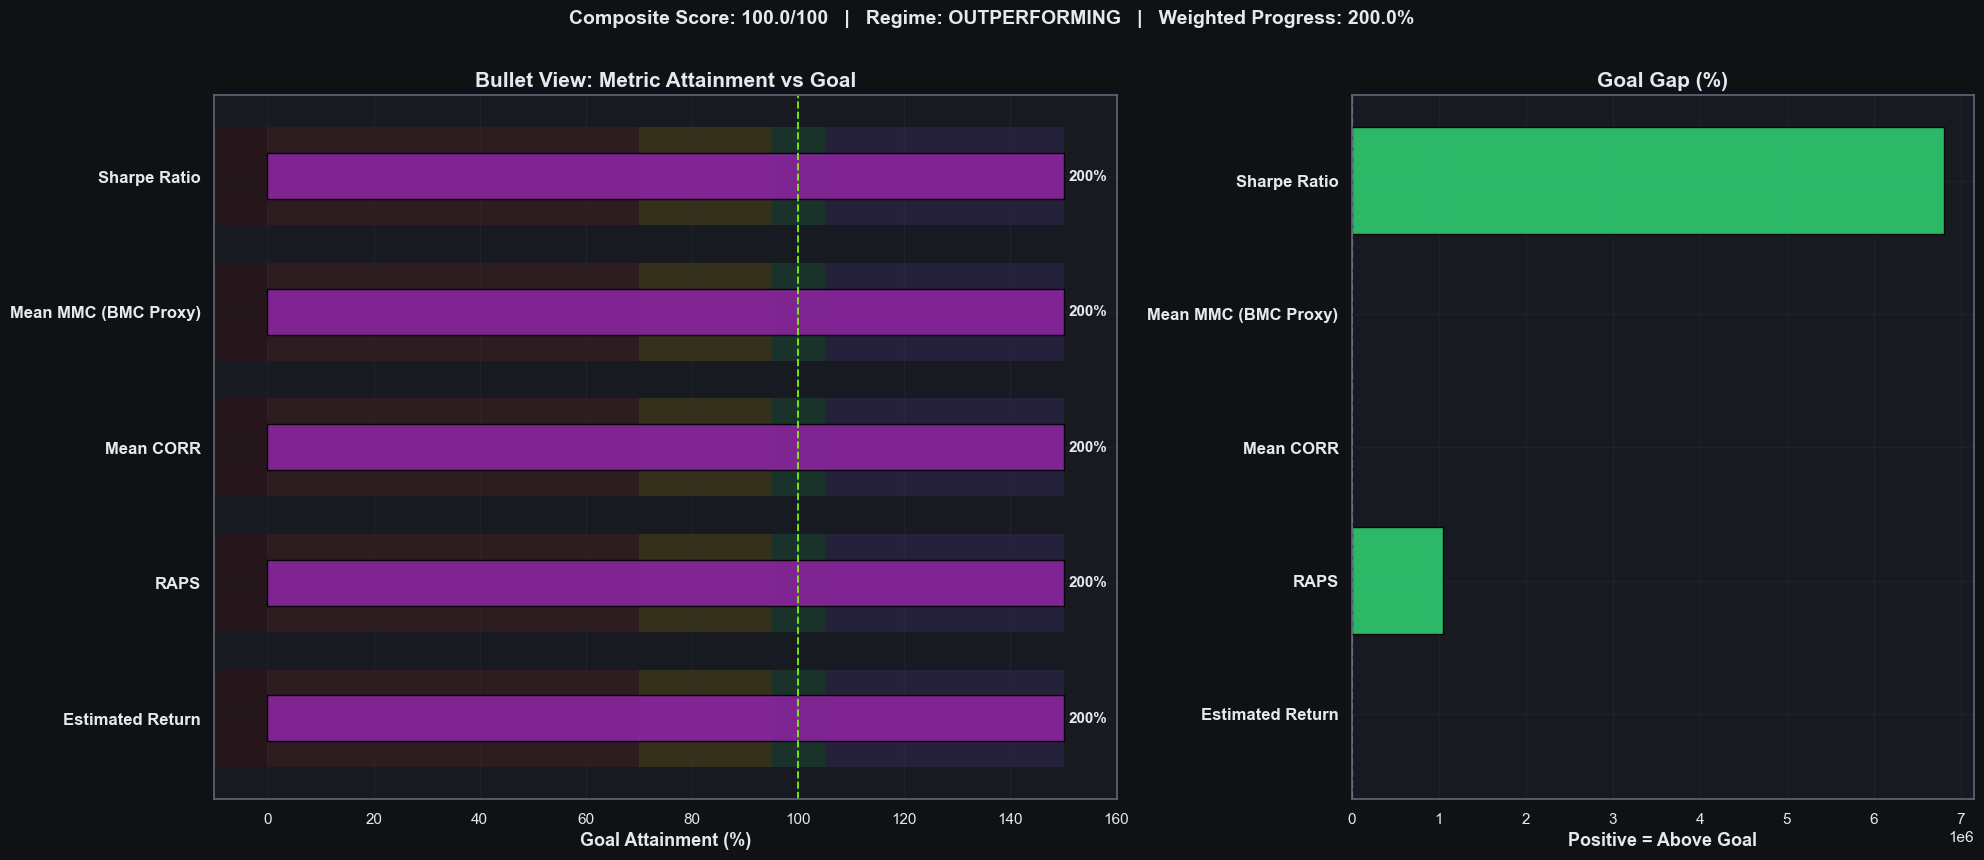

Category,Metric,Value,Goal,Gap %,Progress %,Status,Interpretation
Payout,Estimated Return,+1164.28%,+25.00%,+4557.1%,200.0%,🟣 ABOVE TARGET !!!,"Approximate payout percent using 0.75× CORR + 2.25× MMC, capped at +/-5%"
Payout,Mean CORR,+0.94168,+0.02200,+4180.4%,200.0%,🟣 ABOVE TARGET !!!,Official Numerai correlation score; strong models are often 0.01-0.03
Payout,Mean MMC (BMC Proxy),+0.84083,+0.01000,+8308.3%,200.0%,🟣 ABOVE TARGET !!!,Uniqueness vs benchmark with the current 2.25× payout weight proxy
Payout,RAPS,+1047.7456,+0.1000,+1047645.6%,200.0%,🟣 ABOVE TARGET !!!,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Quality,Win Rate,100.0%,85.0%,+17.6%,117.6%,🟢 MET,Fraction of eras with positive CORR
Quality,Mean FNC,—,+0.01000,—,—,—,CORR after removing linear feature exposure
Risk,Max Drawdown,-0.00000,-0.10000,+100.0%,200.0%,🟣 ABOVE TARGET !!!,Worst sustained CORR cumulative loss
Risk,Payout Sharpe,+1048.1683,+1.2500,+83753.5%,200.0%,🟣 ABOVE TARGET !!!,Sharpe ratio of payout proxy (0.75× CORR + 2.25× MMC)
Risk,Sharpe Ratio,+68122.5928,+1.0000,+6812159.3%,200.0%,🟣 ABOVE TARGET !!!,Risk-adjusted return consistency
Risk,MMC Volatility,+0.00110,—,—,—,—,Standard deviation of era-by-era MMC


In [14]:
metrics, per_era_df = calculate_metrics(
    df_validation=evaluation_frame,
    benchmarks=val_benchmarks,
    features=feature_set,
    target_col=TARGET_COL,
    benchmark_col=BENCHMARK_COL,
    fast_metrics=True,
)

display_metrics_table(metrics, extended=True)

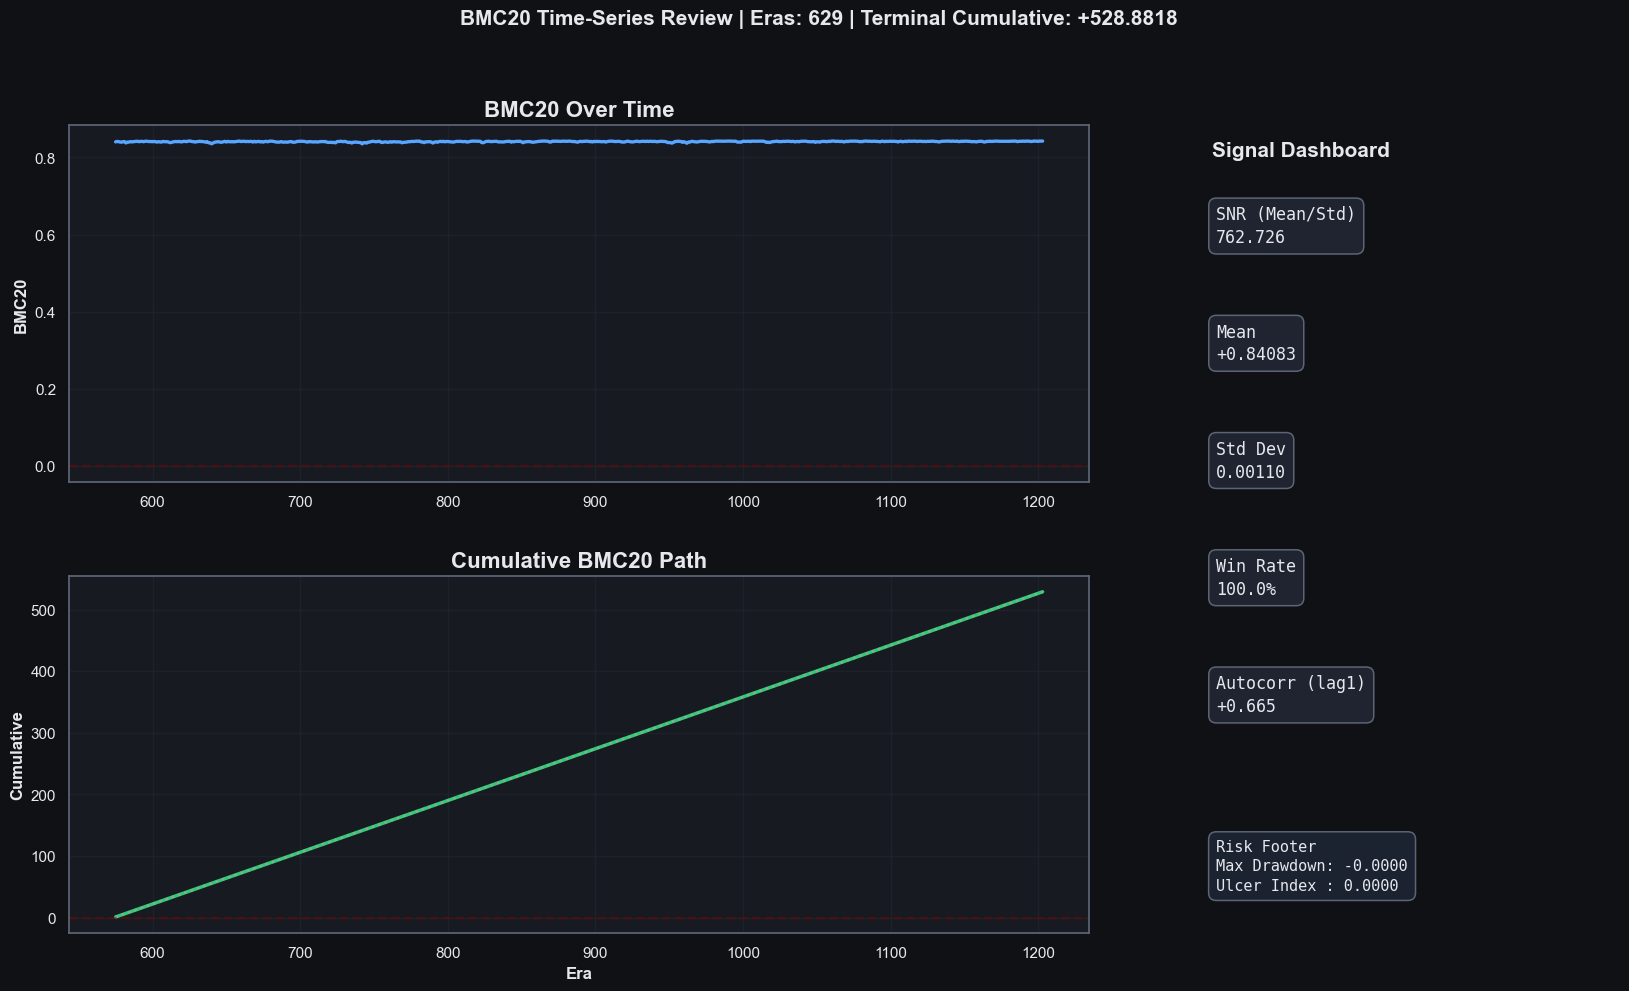

In [15]:
plot_metric_over_time(
        per_era_df=per_era_df,
        metric="BMC20",
    )

In [16]:
# history_df, record = record_model_metrics(
#     metrics=metrics,
#     model_name=MODEL_NAME,
#     notebook_name=NOTEBOOK_PATH.name,
#     force=FORCE_HISTORY_OVERWRITE,
# )
# display(pd.DataFrame([record]))

# leaderboard, is_top_model = compare_top_models_with_current(
#     current_run_id=record["run_id"],
#     top_n=5,
#     show_message=False,
# )
# display(leaderboard)
# print("Top model in history:", is_top_model)

## 5) Breakpoint

In [17]:
assert False, "Inspect metrics and per-era results before retraining on full data."

AssertionError: Inspect metrics and per-era results before retraining on full data.

## 6) Optional Retrain On Full Data

In [ ]:
if not RETRAIN_ON_FULL_DATA:
    print("Set RETRAIN_ON_FULL_DATA = True after removing or bypassing the breakpoint.")
else:
    full_training_frame = pd.concat([train, validation], axis=0)
    full_training_frame = full_training_frame.dropna(subset=[TARGET_COL]).copy()

    final_model = clone(ESTIMATOR)
    final_model.fit(full_training_frame[feature_set], full_training_frame[TARGET_COL])

    print(final_model)
    print("Full-data rows used:", len(full_training_frame))